In [1]:
import pressure_img_generation
from importlib import reload
import matplotlib.pyplot as plt
import output_display
import wave_propagation
import math
import tensorflow as tf
import numpy as np

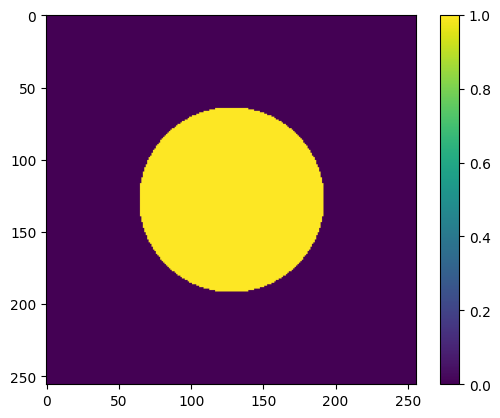

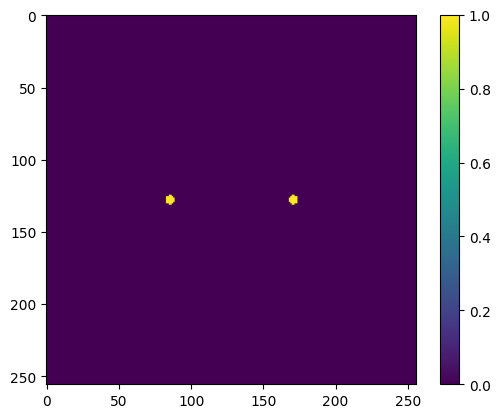

In [2]:
reload(pressure_img_generation)
reload(output_display)

f0 = 1.15e6
#c0 = 6420
c0 = 1480
k = 2*math.pi*f0/c0
N = 256
R = 19.0/2*1e-3
L = 4*R
dx = L/N

z = 10*1e-3

##### Target Amplitude #####
p_target_amp = pressure_img_generation.circle_matrix(N,R/dx*1/20,(N/2,4*N/12))+pressure_img_generation.circle_matrix(N,R/dx*1/20,(N/2,8*N/12))

##### Input #####
#p_0_amp = pressure_img_generation.circle_matrix(N,R/dx)
p_0_amp = pressure_img_generation.circle_matrix(N,R/dx)


# convert to correct datatype
p_0_amp = tf.dtypes.cast(p_0_amp, tf.complex128)
p_target_amp = tf.dtypes.cast(p_target_amp, tf.complex128)


output_display.draw_pressure_complex(p_0_amp)
output_display.draw_pressure_complex(p_target_amp)



In [7]:
reload(wave_propagation)

H_up = wave_propagation.band_limited_propagator(k, N, z, dx)
phasemap = wave_propagation.iasa(p_0_amp,p_target_amp,H_up,drawPressureImage=False)
#phasemap = wave_propagation.diffPAT(p_0_amp,p_target_amp,H_up,drawPressureImage=False)

'p_hologram = p_0_amp*np.exp(1j*phasemap2)\np_image = wave_propagation.propagate(p_hologram,H_up)\noutput_display.draw_phase(phasemap2)\noutput_display.draw_pressure_complex(p_image)'

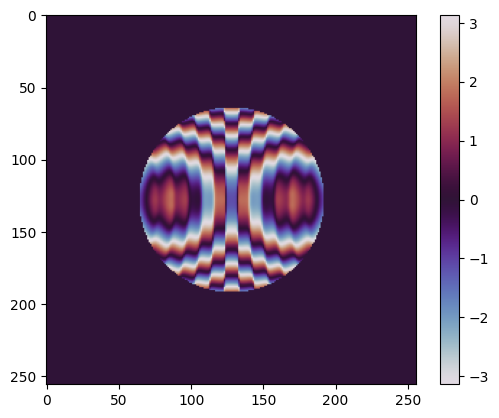

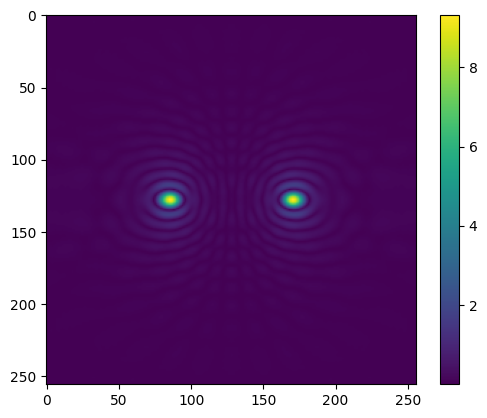

In [8]:
reload(output_display)
p_hologram = p_0_amp*np.exp(1j*phasemap)
p_image = wave_propagation.propagate(p_hologram,H_up)
output_display.draw_phase(phasemap)
output_display.draw_pressure_complex(p_image)

'''p_hologram = p_0_amp*np.exp(1j*phasemap2)
p_image = wave_propagation.propagate(p_hologram,H_up)
output_display.draw_phase(phasemap2)
output_display.draw_pressure_complex(p_image)'''

In [10]:
# c1 > c2
reload(output_display)
from scipy.ndimage import gaussian_filter

c1 = 2600 # formlabs resin
#c1 = 2500 # vero white resin
c2=c0 # h2o
#c2 = 956
#c2 = 1110 # easy flo
f = f0

H = 1/f/(1/c2-1/c1) # max height of hologram
print(H)

delta_z = (phasemap % (2*np.pi)) / (2*np.pi*f*(1/c2-1/c1))

h1 = H-delta_z

h1[p_0_amp==0]=0

h1 = gaussian_filter(h1, sigma=0)



x_values = np.arange(0,N*dx,dx)
y_values = np.arange(0,N*dx,dx)
input_map = p_0_amp.numpy().ravel()




#mesh1 = output_display.heightmap_to_mesh(h1,input_map,x_values,y_values,H=H,R=R,center=(N*dx/2,N*dx/2))
mesh1 = output_display.heightmap_to_mesh(h1,input_map,x_values,y_values)
mesh1.export("test.stl")
#mesh1.export("test.stl")

mesh1.show()

0.0029875776397515525


In [27]:
print(6420/f0)

0.005582608695652174


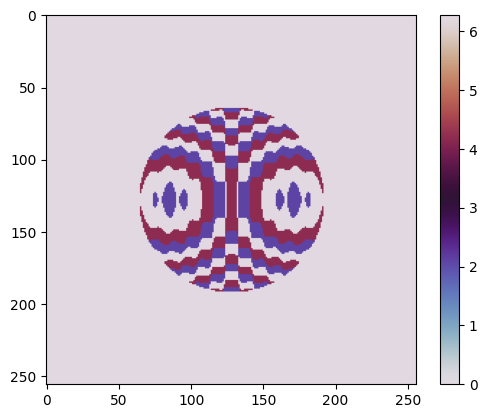

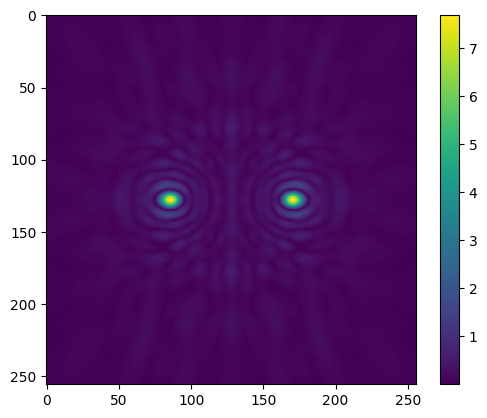

In [14]:
reload(output_display)
reload(wave_propagation)

# change the upper layer material
c_upper_layer = c2
#c_upper_layer = 1110
test_phase_map = ((H-h1) * 2*np.pi*f*(1/c_upper_layer-1/c1)) % (2*math.pi)

# add noise to the phase map
layer_resolution = 1000e-6 # [m]
#print(layer_resolution/H)
#test_phase_map = output_display.add_noise_to_phase(test_phase_map,layer_resolution/H)

# round off the phase map
#print(round(H/layer_resolution))
test_phase_map = output_display.round_off_phase(test_phase_map,round(H/layer_resolution))


# add attenuation
kh = 2*math.pi*f0/c1
#alpha_T = wave_propagation.transmission_coefficient(17.28e6,3e6,1.48e6,kh,h1)
alpha_T = np.ones(h1.shape)

# change the propagation medium
kmedium = k
#kmedium = 2*math.pi*f0/1900
#kmedium = 2*math.pi*f0/1110

# change the propagation distance
#z_up=8.57e-3
z_up=z
#z_up = 6e-3

# simulation
H_up = wave_propagation.band_limited_propagator(kmedium, N, z_up, dx)
p_test_holo = p_0_amp*np.exp(1j*test_phase_map)
p_test_image = np.sqrt(alpha_T)*wave_propagation.propagate(p_test_holo,H_up)
output_display.draw_phase(test_phase_map)
output_display.draw_pressure_complex(p_test_image)
# output_display.draw_pressure_amplitude(alpha_T)